<a href="https://colab.research.google.com/github/piaseckazaneta/30DayMapChallenge2026/blob/main/Day2_2026_Lines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import drive
import sys
import os
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Montowanie Google Drive
drive.mount('/content/drive')

# 2. Ścieżka do Twojego folderu projektu
PROJECT_DIR = '/content/drive/MyDrive/30daymapchallenge2026_Warsaw_pipeline/'

# Dodajemy folder do sys.path, żeby Python widział layout_engine.py
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# 3. Importujemy nasz layout
from layout_engine import setup_linkedin_canvas, finalize_and_save_linkedin_map

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Ścieżka do danych
DATA_DIR = f"{PROJECT_DIR}/Data"

# Wczytanie bazy w metrach (EPSG:2180)
pipeline_gdf = gpd.read_parquet(f"{DATA_DIR}/warszawa_retail_pipeline_final.parquet").to_crs(2180)

# Wydzielenie punktów sieci własnej (50 placówek)
own_stores_pts = pipeline_gdf[pipeline_gdf['has_own_store'] == True].copy()
own_stores_pts['geometry'] = own_stores_pts.geometry.centroid

In [15]:
!pip install -q osmnx
import osmnx as ox

print("Pobieranie sieci drogowej Warszawy z OSM (może potrwać około 30-40s)...")

# 1. Pobieramy graf drogowy z OSM dla obszaru Warszawy
streets_graph = ox.graph_from_place(
    "Warszawa, Poland",
    network_type="drive"
)

# 2. Konwertujemy graf na GeoDataFrames (interesują nas tylko krawędzie, czyli linie ulic)
_, streets_gdf = ox.graph_to_gdfs(streets_graph)

# 3. KROK KRYTYCZNY: Reprojekcja do układu metrycznego EPSG:2180
streets_gdf = streets_gdf.to_crs('EPSG:2180')

# 4. Hierarchia: Główne arterie tranzytowe vs Ulice lokalne
major_types = ['motorway', 'trunk', 'primary']

major_mask = streets_gdf['highway'].apply(
    lambda x: any(t in x for t in major_types) if isinstance(x, list) else x in major_types
)

major_streets = streets_gdf[major_mask]
local_streets = streets_gdf[~major_mask]

print(f"Pobrano łącznie {len(streets_gdf)} odcinków.")
print(f"Główne arterie: {len(major_streets)}")
print(f"Ulice lokalne: {len(local_streets)}")

Pobieranie sieci drogowej Warszawy z OSM (może potrwać około 30-40s)...


KeyboardInterrupt: 

In [11]:
# Pobieramy oficjalną granicę administracyjną Warszawy jako poligon
# Używamy geocodingu OSMnx
warszawa_admin = ox.geocode_to_gdf("Warszawa, Poland")

# Bardzo ważne: reprojekcja do naszego układu metrycznego!
warszawa_admin = warszawa_admin.to_crs("EPSG:2180")

[Export] Saved clean executive map to: day_02_lines_warsaw.png


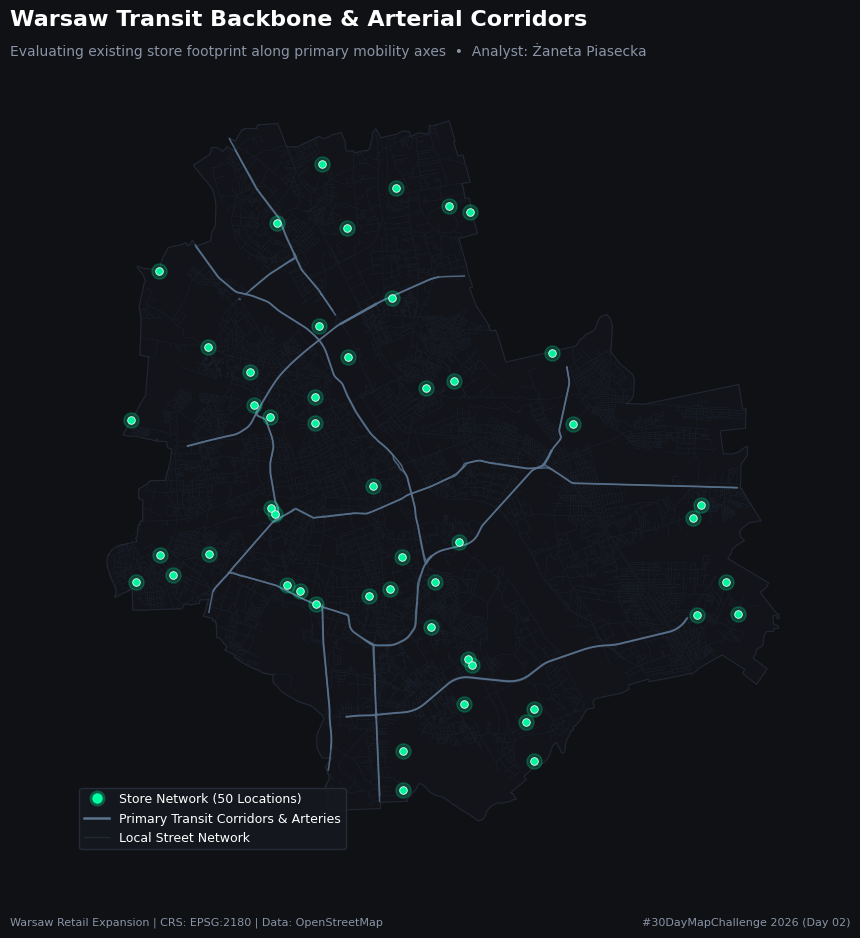

In [21]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# 1. Inicjalizacja canvasu
fig, ax = setup_linkedin_canvas(aspect_ratio="square")

# Warstwa 0: Obrys administracyjny Warszawy
warszawa_admin.plot(
    ax=ax,
    facecolor="#12141A",
    edgecolor="#222733",
    linewidth=0.8,
    zorder=1
)

# Warstwa 1: Tkanka lokalna (subtelna, niska grubość i przezroczystość)
local_streets.plot(
    ax=ax,
    color="#2A3342",
    linewidth=0.35,
    alpha=0.25,
    zorder=2
)

# Warstwa 2: Główne arterie i korytarze tranzytowe (jaśniejszy, chłodny błękit/stal)
major_streets.plot(
    ax=ax,
    color="#5A738E",
    linewidth=1.1,
    alpha=0.85,
    zorder=3
)

# Warstwa 3a: Efekt poświaty dla 50 sklepów własnych
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    markersize=120,
    alpha=0.20,
    zorder=4
)

# Warstwa 3b: Właściwe punkty sieci
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    edgecolor="#FFFFFF",
    linewidth=0.6,
    markersize=30,
    alpha=0.95,
    zorder=5
)

# 4. Spójna legenda (zgodna ze standardem z Dnia 1)
mint_hex = "#00FFA3"
mint_glow_rgba = to_rgba(mint_hex, alpha=0.30)

custom_handles = [
    # 1. Punkty (0D)
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=f'Store Network ({len(own_stores_pts)} Locations)',
        markerfacecolor=mint_hex,
        markeredgecolor=mint_glow_rgba,
        markeredgewidth=4.0,
        markersize=7.5
    ),
    # 2. Linie główne (1D)
    Line2D(
        [0], [0],
        color="#5A738E",
        linewidth=1.8,
        label="Primary Transit Corridors & Arteries"
    ),
    # 3. Linie podrzędne (1D)
    Line2D(
        [0], [0],
        color="#2A3342",
        linewidth=1.0,
        alpha=0.6,
        label="Local Street Network"
    )
]

legend = ax.legend(
    handles=custom_handles,
    loc="lower left",
    frameon=True,
    facecolor="#161920",
    edgecolor="#2A2F3D",
    fontsize=9,
    labelcolor="#FFFFFF"
)
legend.get_frame().set_alpha(0.85)

# 5. Finalizacja i eksport
finalize_and_save_linkedin_map(
    fig=fig,
    ax=ax,
    main_title="Warsaw Transit Backbone & Arterial Corridors",
    subtitle="Evaluating existing store footprint along primary mobility axes",
    author_name="Żaneta Piasecka",
    day_num=2,
    output_filename="day_02_lines_warsaw.png"
)

plt.show()